In [27]:
# initializing the notebook with necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
# loading the dataset from the source folder
data = pd.read_csv('../source/player1.csv')
print(data)

    match_id  kills  damage  placement  survival_time  headshots  win
0          1    2.0   185.0       23.0             12        0.0    0
1          2    5.0   640.0        7.0             24        2.0    0
2          3    0.0    35.0       89.0              3        0.0    0
3          4    7.0   890.0        2.0             28        3.0    0
4          5    3.0   310.0       14.0             19        1.0    0
5          6   12.0  1450.0        1.0             31        6.0    1
6          7    1.0    95.0       44.0              8        0.0    0
7          8    NaN   420.0       16.0             21        1.0    0
8          9    4.0   380.0       11.0             18        2.0    0
9         10    2.0   210.0       25.0             13        NaN    0
10        11    6.0   720.0        5.0             26        3.0    0
11        12    3.0   290.0       19.0             17        1.0    0
12        13    9.0  1100.0        3.0             29        4.0    0
13        14    0.0 

In [29]:
# getting the basic info and statistics of the dataset
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   match_id       40 non-null     int64  
 1   kills          39 non-null     float64
 2   damage         39 non-null     float64
 3   placement      39 non-null     float64
 4   survival_time  40 non-null     int64  
 5   headshots      39 non-null     float64
 6   win            40 non-null     int64  
dtypes: float64(4), int64(3)
memory usage: 2.3 KB


,match_id,kills,damage,placement,survival_time,headshots,win
count,40.000000,39.000000,39.000000,39.000000,40.000000,39.000000,40.000000
mean,20.500000,29.615385,607.051282,22.923077,18.675000,2.000000,0.075000
std,11.690452,159.346134,850.986825,24.922390,8.434932,2.328315,0.266747
min,1.000000,-1.000000,0.000000,1.000000,2.000000,0.000000,0.000000
25%,10.750000,2.000000,187.500000,6.000000,12.750000,1.000000,0.000000
50%,20.500000,3.000000,380.000000,14.000000,19.500000,1.000000,0.000000
75%,30.250000,6.000000,710.000000,28.500000,25.000000,2.500000,0.000000
max,40.000000,999.000000,5000.000000,95.000000,33.000000,12.000000,1.000000


In [30]:
# checking for missing values
data.isnull().sum()

match_id         0
kills            1
damage           1
placement        1
survival_time    0
headshots        1
win              0
dtype: int64

In [31]:
# Fix the missing values using median for numerical columns and mode for categorical columns
num_cols = ['kills', 'damage', 'placement', 'survival_time', 'headshots']
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [32]:
 
data[['kills','damage','placement','survival_time','headshots']].describe()

,kills,damage,placement,survival_time,headshots
count,40.000000,40.000000,40.00000,40.000000,40.000000
mean,28.950000,601.375000,22.70000,18.675000,1.975000
std,157.346254,840.772681,24.64122,8.434932,2.303704
min,-1.000000,0.000000,1.00000,2.000000,0.000000
25%,2.000000,188.750000,6.00000,12.750000,1.000000
50%,3.000000,380.000000,14.00000,19.500000,1.000000
75%,6.000000,705.000000,28.25000,25.000000,2.250000
max,999.000000,5000.000000,95.00000,33.000000,12.000000


In [33]:
# Removing the extreme outliers (using IQR)
data['kills'] = data['kills'].apply(lambda x: max(x,0))
data['damage'] = data['damage'].apply(lambda x: max(x,0))
data['placement'] = data['placement'].apply(lambda x: max(x,1))
data['survival_time'] = data['survival_time'].apply(lambda x: max(x,1))
data['headshots'] = data['headshots'].apply(lambda x: max(x,0))

In [34]:
for col in ['kills','damage','survival_time','headshots']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    data[col] = np.where(data[col] > upper, upper, data[col])
    data[col] = np.where(data[col] < lower, lower, data[col])

In [35]:
data.to_csv('../outputs/cleaned_data.csv', index=False)

In [36]:
avg_kills = data['kills'].mean()
avg_damage = data['damage'].mean()
print(f"Average kills per match: {avg_kills:.2f}")
print(f"Average damage per match: {avg_damage:.2f}")

Average kills per match: 4.22
Average damage per match: 495.34


In [37]:
if 'win' in data.columns:
    win_rate = data['win'].mean()
    print(f"Win rate: {win_rate*100:.2f}%")

Win rate: 7.50%


In [38]:
corr = data.corr()
corr

,match_id,kills,damage,placement,survival_time,headshots,win
match_id,1.000000,-0.037453,-0.027752,0.013352,0.008191,0.015779,-0.127449
kills,-0.037453,1.000000,0.992863,-0.724046,0.917736,0.961595,0.677624
damage,-0.027752,0.992863,1.000000,-0.693059,0.907794,0.955081,0.674930
placement,0.013352,-0.724046,-0.693059,1.000000,-0.901045,-0.742180,-0.253954
survival_time,0.008191,0.917736,0.907794,-0.901045,1.000000,0.925991,0.455557
headshots,0.015779,0.961595,0.955081,-0.742180,0.925991,1.000000,0.536174
win,-0.127449,0.677624,0.674930,-0.253954,0.455557,0.536174,1.000000


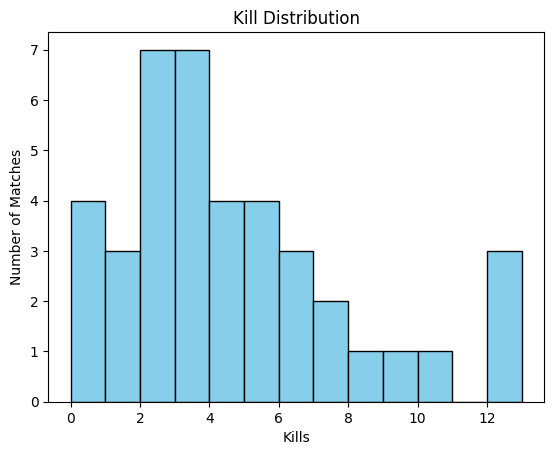

In [39]:
plt.hist(data['kills'], bins=range(0,int(data['kills'].max())+2), color='skyblue', edgecolor='black')
plt.title('Kill Distribution')
plt.xlabel('Kills')
plt.ylabel('Number of Matches')
plt.show()

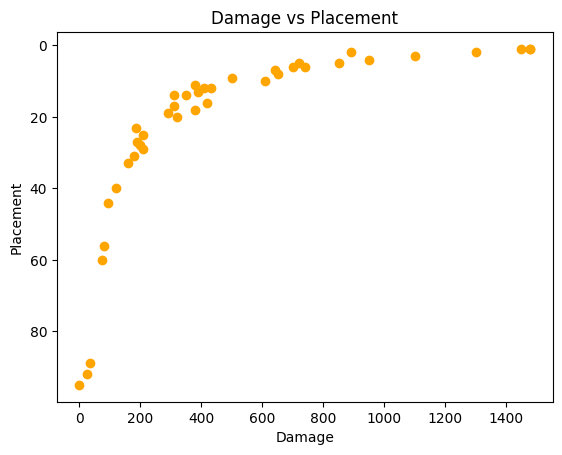

In [40]:
plt.scatter(data['damage'], data['placement'], color='orange')
plt.title('Damage vs Placement')
plt.xlabel('Damage')
plt.ylabel('Placement')
plt.gca().invert_yaxis()
plt.show()

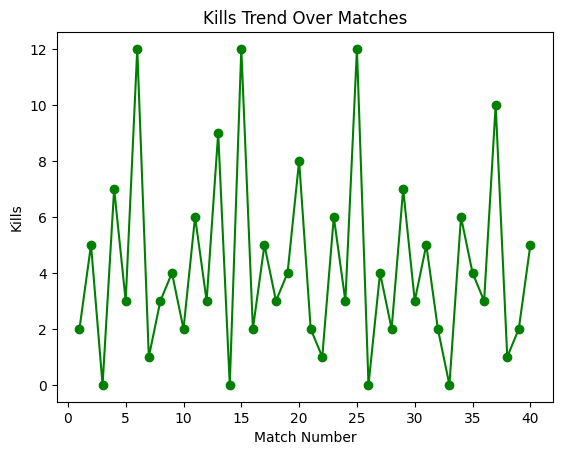

In [41]:
plt.plot(range(1,len(data)+1), data['kills'], marker='o', linestyle='-', color='green')
plt.title('Kills Trend Over Matches')
plt.xlabel('Match Number')
plt.ylabel('Kills')
plt.show()

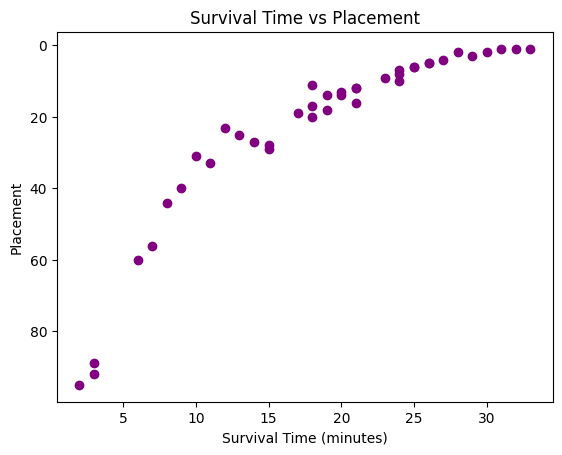

In [42]:
plt.scatter(data['survival_time'], data['placement'], color='purple')
plt.title('Survival Time vs Placement')
plt.xlabel('Survival Time (minutes)')
plt.ylabel('Placement')
plt.gca().invert_yaxis()
plt.show()

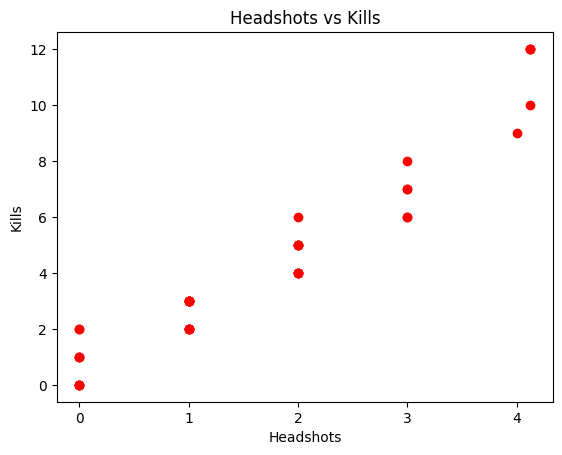

In [43]:
plt.scatter(data['headshots'], data['kills'], color='red')
plt.title('Headshots vs Kills')
plt.xlabel('Headshots')
plt.ylabel('Kills')
plt.show()

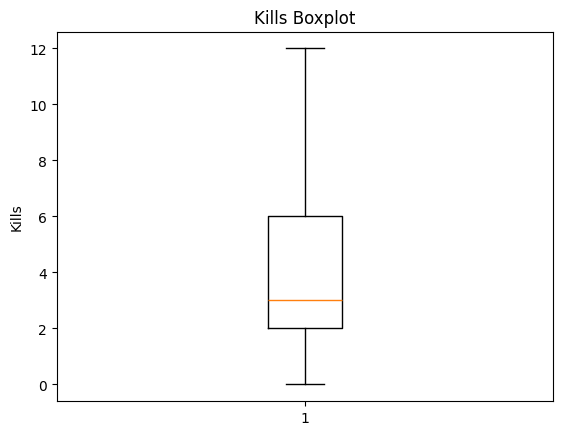

In [44]:
plt.boxplot(data['kills'])
plt.title('Kills Boxplot')
plt.ylabel('Kills')
plt.show()

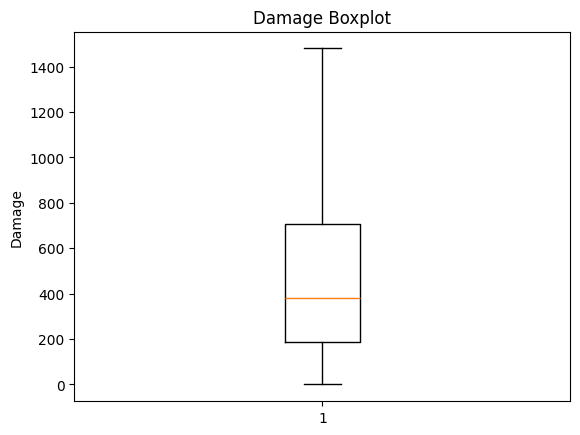

In [45]:
plt.boxplot(data['damage'])
plt.title('Damage Boxplot')
plt.ylabel('Damage')
plt.show()

In [46]:
top_matches = data.sort_values('damage', ascending=False).head(5)
top_matches[['match_id','kills','damage','placement','win']]

,match_id,kills,damage,placement,win
24,25,12.0,1479.375,1.0,1
14,15,12.0,1479.375,1.0,1
5,6,12.0,1450.000,1.0,1
36,37,10.0,1300.000,2.0,0
12,13,9.0,1100.000,3.0,0
